Possible combinations for following topology:
q0 -- q1
|     |
q2 -- q3


In [19]:
import itertools

perms = list(itertools.permutations(["q0", "q1", "q2", "a0"]))
perms

[('q0', 'q1', 'q2', 'a0'),
 ('q0', 'q1', 'a0', 'q2'),
 ('q0', 'q2', 'q1', 'a0'),
 ('q0', 'q2', 'a0', 'q1'),
 ('q0', 'a0', 'q1', 'q2'),
 ('q0', 'a0', 'q2', 'q1'),
 ('q1', 'q0', 'q2', 'a0'),
 ('q1', 'q0', 'a0', 'q2'),
 ('q1', 'q2', 'q0', 'a0'),
 ('q1', 'q2', 'a0', 'q0'),
 ('q1', 'a0', 'q0', 'q2'),
 ('q1', 'a0', 'q2', 'q0'),
 ('q2', 'q0', 'q1', 'a0'),
 ('q2', 'q0', 'a0', 'q1'),
 ('q2', 'q1', 'q0', 'a0'),
 ('q2', 'q1', 'a0', 'q0'),
 ('q2', 'a0', 'q0', 'q1'),
 ('q2', 'a0', 'q1', 'q0'),
 ('a0', 'q0', 'q1', 'q2'),
 ('a0', 'q0', 'q2', 'q1'),
 ('a0', 'q1', 'q0', 'q2'),
 ('a0', 'q1', 'q2', 'q0'),
 ('a0', 'q2', 'q0', 'q1'),
 ('a0', 'q2', 'q1', 'q0')]

In [24]:
import networkx as nx


for perm in perms:
    module = nx.Graph()
    q0, q1, q2, a0 = perm
    edgelist = set([(q0, q1), (q1, q2), (q2, a0), (a0, q0)])
    module.add_nodes_from(["q0", "q1", "q2", "a0"])
    module.add_edge(q0, q1, weight=0.996, type="state")
    module.add_edge(q1, q2, weight=0.995, type="state")
    module.add_edge(q2, a0, weight=0.994, type="state")
    module.add_edge(a0, q0, weight=0.995, type="ancilla")



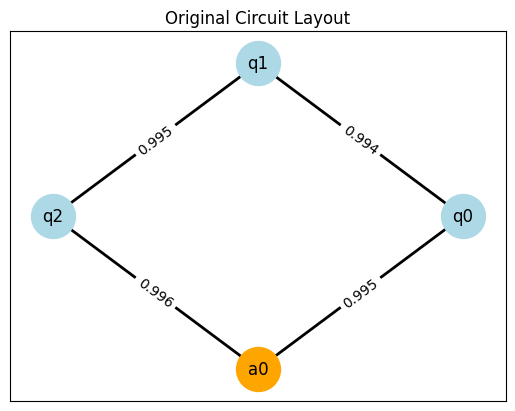

In [23]:
import matplotlib.pyplot as plt

pos = nx.circular_layout(module)
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="orange")
nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
nx.draw_networkx_edges(module, pos, width=2)
nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
plt.title("Original Circuit Layout")
plt.show()

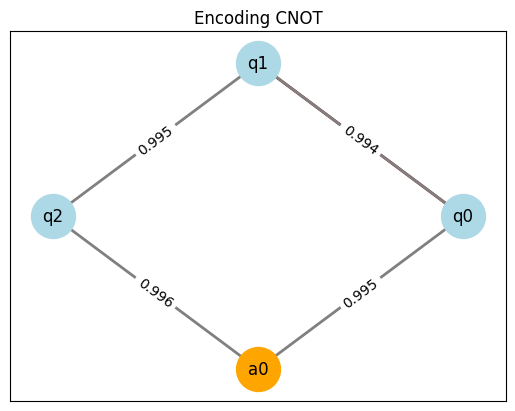

In [27]:
from networkx import draw


pos = nx.circular_layout(module)
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["q0", "q1", "q2"], node_color="lightblue")
nx.draw_networkx_nodes(module, pos, node_size=1000, nodelist= ["a0"], node_color="orange")
nx.draw_networkx_labels(module, pos, font_size=12, font_family="sans-serif")
nx.draw_networkx_edges(module, pos, edgelist=[("q0", "q1")], edge_color="darkred", width=2)
nx.draw_networkx_edges(module, pos, edgelist=edgelist - {("q0", "q1")}, edge_color="gray", width=2)
nx.draw_networkx_edge_labels(module, pos, edge_labels=nx.get_edge_attributes(module, "weight"))
plt.title("Encoding CNOT")
plt.show()